# Set up workspace

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
from cartopy.util import add_cyclic_point
import cartopy.crs as ccrs

In [5]:
import sys
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

In [6]:
from load_gridcell_areas import *

In [7]:
path_in='/glade/work/czarakas/coupled_PPE/data/data_for_figures/'

# Load data

In [8]:
ds_Ts = xr.open_dataset(path_in+'annual_means/delta_TSKIN_Annual_mean_coupled.nc')['TSKIN']
pvals_Ts=xr.open_dataset(path_in+'annual_means/pval_TSKIN_Annual_mean_coupled.nc')['pval']

In [9]:
ds_P = xr.open_dataset(path_in+'annual_means/delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']
pvals_P=xr.open_dataset(path_in+'annual_means/pval_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['pval']

In [10]:
ds_ref_P=xr.open_dataset(path_in+'annual_means/ref_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']
ds_ref_Ts=xr.open_dataset(path_in+'annual_means/ref_TSKIN_Annual_mean_coupled.nc')['TSKIN']

In [11]:
landweights2_atm=landweights2.reindex_like(ds_ref_P, method='nearest',tolerance=0.05)
landweights2_lnd=landweights2

# Do some calculations

In [12]:
val_range=ds_P.max(dim='ensemble_key')-ds_P.min(dim='ensemble_key')
val_range_mmyear=val_range*86400*365

In [13]:
val_range_pct=val_range*100/ds_ref_P

# Figure S11

In [14]:
#method 1: no FDR
sigmask=((pvals_P<=0.05).sum(dim='ensemble_key')<=5)

In [15]:
# method 2: with FDR analysis
from FDR_analysis import *

K=(landweights2.values.flatten()>0).sum()
sig_change_P=calculate_sig_changes_FDR(pvals_P, 
                              K=K,
                              alpha_global=0.05)

#pct_change_Ts=((sig_change_Ts)*landweights2).sum(dim=['lat','lon'])*100
sigmask=(sig_change_P.sum(dim='ensemble_key')<=5)

/glade/u/ssg/ch/usr/jupyterhub/envs/pangeo-2019.09.12/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in greater
  after removing the cwd from sys.path.


In [16]:
plt.rcParams.update({'hatch.color': 'gray'})

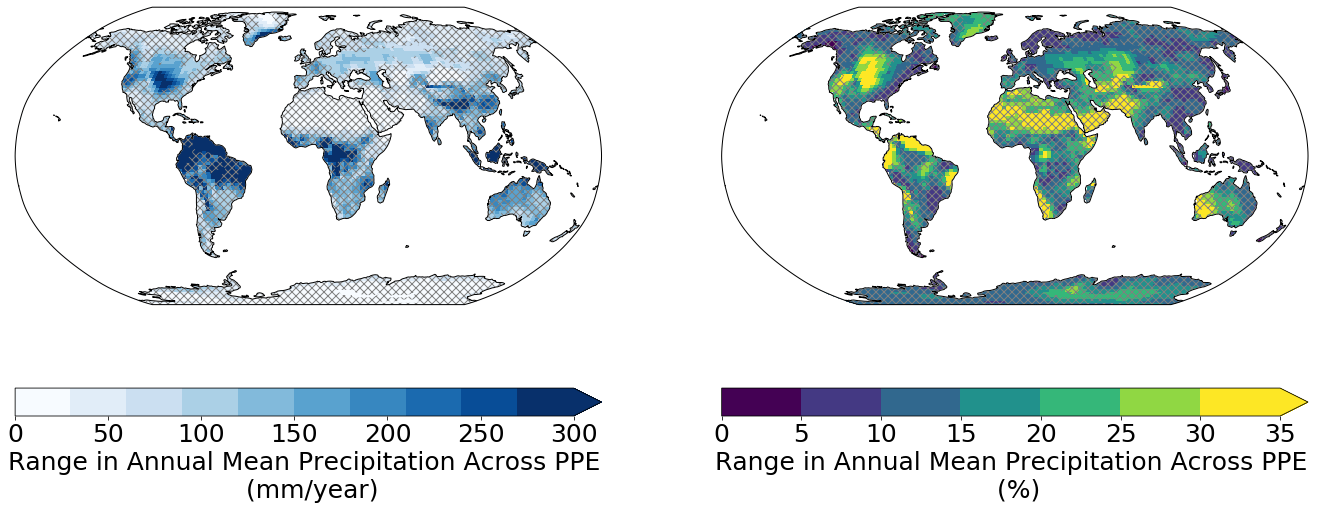

In [17]:
plt.rcParams.update({'font.size': 25})
#fig = plt.figure()
fig, (ax1, ax2) = plt.subplots(figsize=(20,9),ncols=2, subplot_kw={'projection': ccrs.Robinson()})

#plt.subplot(1,2,1)
#ax2 = plt.axes(projection=ccrs.Robinson())
ax1.set_global()
mapdata=val_range_mmyear
cyclic_data, cyclic_lons = add_cyclic_point(mapdata, coord=mapdata.lon)

im1=ax1.pcolormesh(cyclic_lons, mapdata.lat, #contourf
                   cyclic_data, 
                   cmap=plt.cm.get_cmap("Blues",10), vmin=0, vmax=300,#levels=np.arange(-100,100),
                   transform=ccrs.PlateCarree())
plt.colorbar(im1, extend='max', orientation='horizontal',ax=ax1,
            label='Range in Annual Mean Precipitation Across PPE \n (mm/year)')#, ticks=np.arange(-0.025, 0.030, 0.005))

cyclic_data_mask, cyclic_lons_mask = add_cyclic_point(sigmask, coord=sigmask.lon)
ax1.contourf(
            cyclic_lons_mask, sigmask.lat, cyclic_data_mask,
            transform=ccrs.PlateCarree(),
            colors='none',
            levels=[0.5, 1.5],
            hatches=['xxx'])
        
ax1.add_feature(cartopy.feature.OCEAN, facecolor='white', zorder=1)
ax1.coastlines()

#plt.subplot(1,2,2)
mapdata=val_range_pct
#ax = plt.axes(projection=ccrs.Robinson())
ax2.set_global()

cyclic_data, cyclic_lons = add_cyclic_point(mapdata, coord=mapdata.lon)

im2=ax2.pcolormesh(cyclic_lons, mapdata.lat, #contourf
                   cyclic_data, 
                   cmap=plt.cm.get_cmap("viridis",7), vmin=0, vmax=35,#levels=np.arange(-100,100),
                   transform=ccrs.PlateCarree())
plt.colorbar(im2, extend='max', orientation='horizontal',ax=ax2,
            label='Range in Annual Mean Precipitation Across PPE \n (%)')#, ticks=np.arange(-0.025, 0.030, 0.005))
cyclic_data_mask, cyclic_lons_mask = add_cyclic_point(sigmask, coord=sigmask.lon)
ax2.contourf(
            cyclic_lons_mask, sigmask.lat, cyclic_data_mask,
            transform=ccrs.PlateCarree(),
            colors='none',
            levels=[0.5, 1.5],
            hatches=['xxx'])
        
plt.tight_layout()
ax2.add_feature(cartopy.feature.OCEAN, facecolor='white', zorder=1)
ax2.coastlines()
#plt.savefig('Figures/PRECT_range_absolute_change.pdf')